🧠 Pelatihan Agen 'Observant' (150.000 langkah)...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 100      |
|    ep_rew_mean     | -1.8e+03 |
| time/              |          |
|    fps             | 4679     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 100         |
|    ep_rew_mean          | -1.67e+03   |
| time/                   |             |
|    fps                  | 3268        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.012037799 |
|    clip_fraction        | 0.0164      |
|    clip_ra

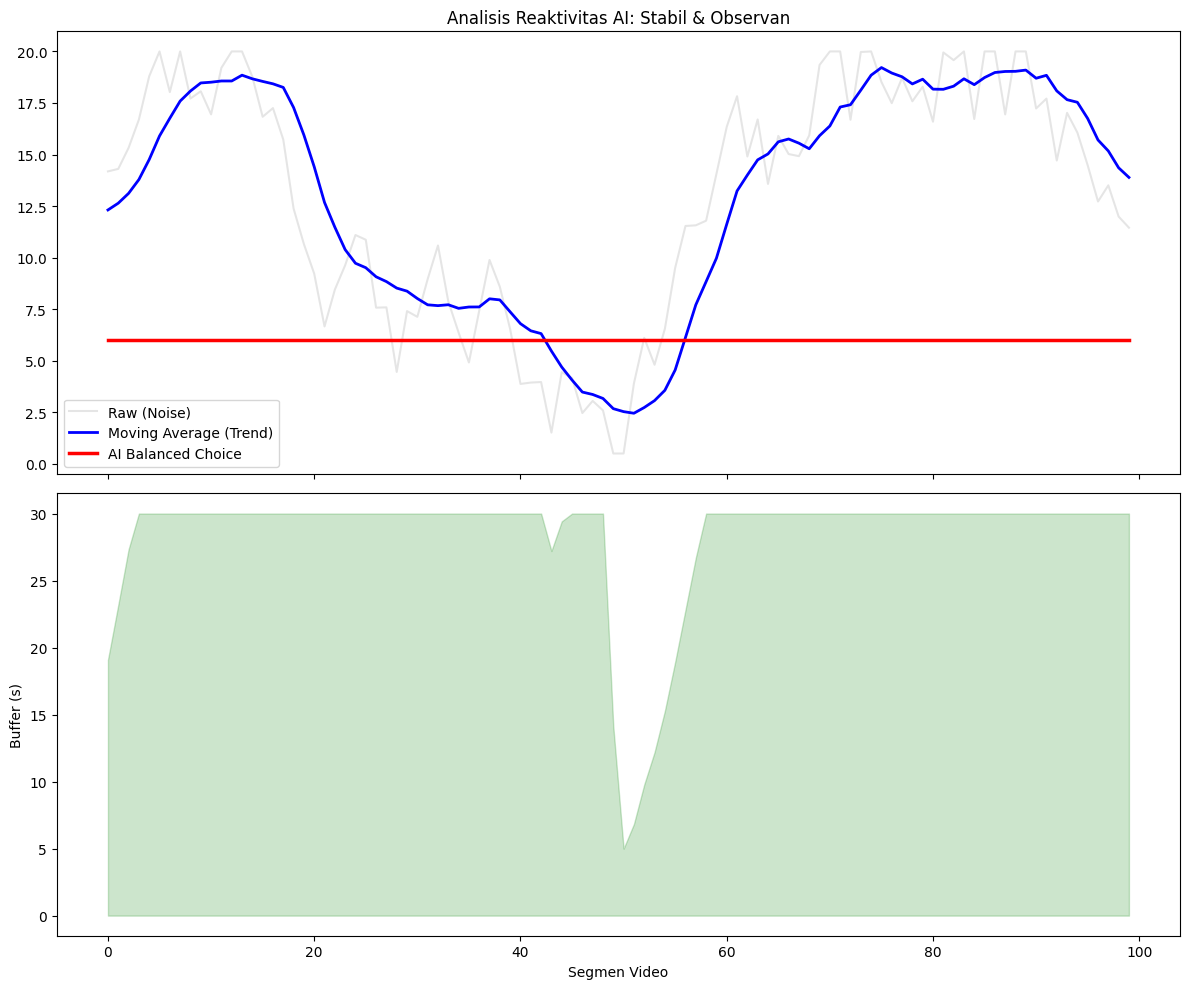

In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from stable_baselines3 import PPO
import matplotlib.pyplot as plt
import pandas as pd
from collections import deque

class SmoothedShakaEnv(gym.Env):
    """
    Simulator Shaka NDN dengan fitur Moving Average & Trend Awareness.
    Didesain agar reaktif namun tetap stabil (anti-flicker).
    """
    def __init__(self, window_size=5):
        super(SmoothedShakaEnv, self).__init__()
        self.window_size = window_size
        self.throughput_history = deque(maxlen=window_size)
        self.buffer_history = deque(maxlen=3) # Untuk mendeteksi tren naik/turun buffer
        
        # Action: 0=Low (0.5), 1=Mid (2.5), 2=High (8.0 Mbps)
        self.action_space = spaces.Discrete(3)
        self.bitrates = [0.5, 2.5, 8.0]
        
        # Obs: [Buffer, Avg_TP, LastQual, Buffer_Trend, RTT]
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, -5, 0]),
            high=np.array([30, 20, 2, 5, 1000]),
            dtype=np.float32
        )
        self.state = None
        self.max_steps = 100

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        initial_tp = 12.0
        for _ in range(self.window_size):
            self.throughput_history.append(initial_tp)
        
        self.buffer_history.clear()
        self.buffer_history.append(15.0)
            
        self.state = np.array([15.0, initial_tp, 1.0, 0.0, 40.0], dtype=np.float32)
        self.current_step = 0
        return self.state, {}

    def step(self, action):
        buffer, _, last_qual, _, rtt = self.state
        chosen_bitrate = self.bitrates[action]
        
        # 1. Simulasi Realitas (Instan dengan Noise)
        raw_throughput = np.clip(self.throughput_history[-1] + np.random.uniform(-3.5, 3.5), 0.5, 20.0)
        
        seg_dur = 5.0
        download_time = (chosen_bitrate * seg_dur / (raw_throughput + 0.1)) + (rtt / 1000.0)
        
        stalling = max(0, download_time - buffer)
        new_buffer = max(0, buffer - download_time) + seg_dur
        new_buffer = min(new_buffer, 30.0)

        # Hitung Tren Buffer (apakah sedang terkuras?)
        buffer_trend = new_buffer - buffer
        self.buffer_history.append(new_buffer)

        # 2. Update History & Smoothing
        self.throughput_history.append(raw_throughput)
        avg_throughput = sum(self.throughput_history) / len(self.throughput_history)

        # 3. LOGIKA REWARD (Tuning Presisi)
        # Dasar: Gunakan Log untuk nilai bitrate agar tidak jomplang
        reward = np.log2(chosen_bitrate + 1) * 5.0

        # Penalti Stalling (Sangat Fatal)
        if stalling > 0:
            reward -= 200.0
            
        # Switching Penalty (Mencegah Reaktivitas Berlebih)
        # Penalti lebih besar jika pindah kualitas saat internet tidak stabil
        reward -= abs(action - last_qual) * 6.0
        
        # PENALTI RISIKO (The "Observer" Logic)
        # Jika bitrate yang dipilih > throughput rata-rata, beri penalti risiko
        if chosen_bitrate > avg_throughput:
            reward -= (chosen_bitrate - avg_throughput) * 10.0
            
        # PENALTI TREN NEGATIF
        # Jika buffer sedang turun (trend < 0) dan kita tetap di kualitas High
        if buffer_trend < 0 and action == 2:
            reward -= abs(buffer_trend) * 5.0

        # Update State
        self.state = np.array([new_buffer, avg_throughput, float(action), buffer_trend, rtt], dtype=np.float32)
        
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self.state, reward, done, False, {"raw_tp": raw_throughput}

def run_experiment():
    print("🧠 Pelatihan Agen 'Observant' (150.000 langkah)...")
    env = SmoothedShakaEnv(window_size=7) # Window diperlebar untuk pengamatan lebih lama
    
    # Learning rate diperkecil agar belajar lebih teliti
    model = PPO("MlpPolicy", env, verbose=1, learning_rate=0.00015, ent_coef=0.01)
    model.learn(total_timesteps=150000)
    
    # Testing
    obs, _ = env.reset()
    history = []
    for i in range(100):
        # Skenario: Internet naik-turun dengan pola yang lebih menantang
        if 20 <= i <= 40: obs[1] = np.random.uniform(3, 5)   # Lemot
        if 41 <= i <= 70: obs[1] = np.random.uniform(12, 16) # Lonjakan
        if 71 <= i <= 100: obs[1] = np.random.uniform(5, 7)  # Turun lagi
            
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        
        history.append({
            'Step': i,
            'Raw_TP': info['raw_tp'],
            'Avg_TP': obs[1],
            'Buffer': obs[0],
            'Quality': action
        })

    df = pd.DataFrame(history)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    ax1.plot(df['Step'], df['Raw_TP'], label='Raw (Noise)', color='gray', alpha=0.2)
    ax1.plot(df['Step'], df['Avg_TP'], label='Moving Average (Trend)', color='blue', linewidth=2)
    ax1.step(df['Step'], df['Quality'] * 4 + 2, label='AI Balanced Choice', color='red', linewidth=2.5)
    ax1.set_title("Analisis Reaktivitas AI: Stabil & Observan")
    ax1.legend()
    
    ax2.fill_between(df['Step'], df['Buffer'], color='green', alpha=0.2)
    ax2.set_ylabel("Buffer (s)")
    ax2.set_xlabel("Segmen Video")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_experiment()